<a href="https://colab.research.google.com/github/viktory-41/Telco_Customer_Churn/blob/main/Telco_Customer_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Колонки:

customerID — уникальный ID

gender — пол

SeniorCitizen — пенсионер (0/1)

Partner — есть партнер (Yes/No)

Dependents — есть иждивенцы

tenure — сколько месяцев с компанией

PhoneService — есть телефонная услуга

MultipleLines — несколько линий

InternetService — тип интернета (DSL/Fiber optic/No)

OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies — дополнительные услуги

Contract — тип контракта (Month-to-month/One year/Two year)

PaperlessBilling — электронные счета

PaymentMethod — способ оплаты

MonthlyCharges — ежемесячный платеж

TotalCharges — всего заплачено

Churn — ушел ли клиент (Yes/No)

In [5]:
df= pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.shape

(7043, 21)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')
print(df['TotalCharges'].info())

<class 'pandas.core.series.Series'>
RangeIndex: 7043 entries, 0 to 7042
Series name: TotalCharges
Non-Null Count  Dtype  
--------------  -----  
7032 non-null   float64
dtypes: float64(1)
memory usage: 55.2 KB
None


In [9]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [10]:
df=df.dropna()
print(df.shape)

(7032, 21)


In [11]:
df.nunique()


,0
customerID,7032
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,72
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3


In [12]:
print("\nБазовая статистика числовых признаков:")
print(df.describe())


Базовая статистика числовых признаков:
       SeniorCitizen       tenure  MonthlyCharges  TotalCharges
count    7032.000000  7032.000000     7032.000000   7032.000000
mean        0.162400    32.421786       64.798208   2283.300441
std         0.368844    24.545260       30.085974   2266.771362
min         0.000000     1.000000       18.250000     18.800000
25%         0.000000     9.000000       35.587500    401.450000
50%         0.000000    29.000000       70.350000   1397.475000
75%         0.000000    55.000000       89.862500   3794.737500
max         1.000000    72.000000      118.750000   8684.800000


In [13]:
chur_count=df["Churn"].value_counts()
print(chur_count)
print(chur_count['Yes']/len(df)*100)

Churn
No     5163
Yes    1869
Name: count, dtype: int64
26.578498293515356


/tmp/ipykernel_217/341322527.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_tenure = df.groupby('tenure_group')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
/tmp/ipykernel_217/341322527.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_monthly = df.groupby('monthly_group')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)


<Figure size 1000x600 with 0 Axes>

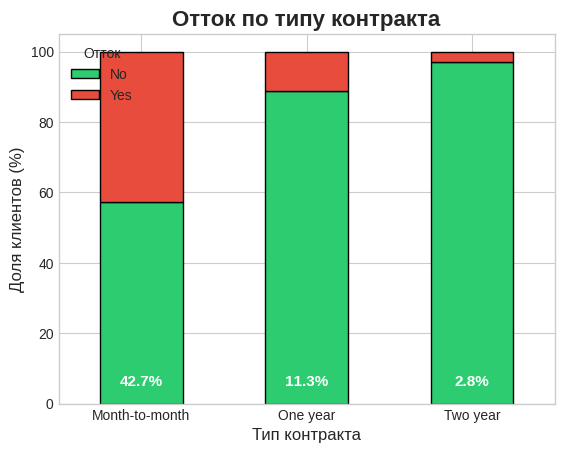

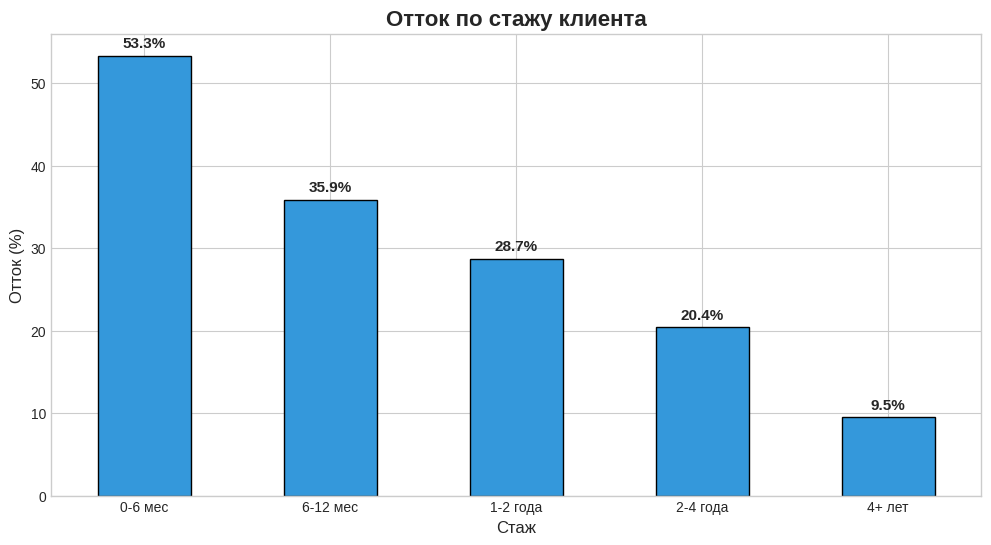

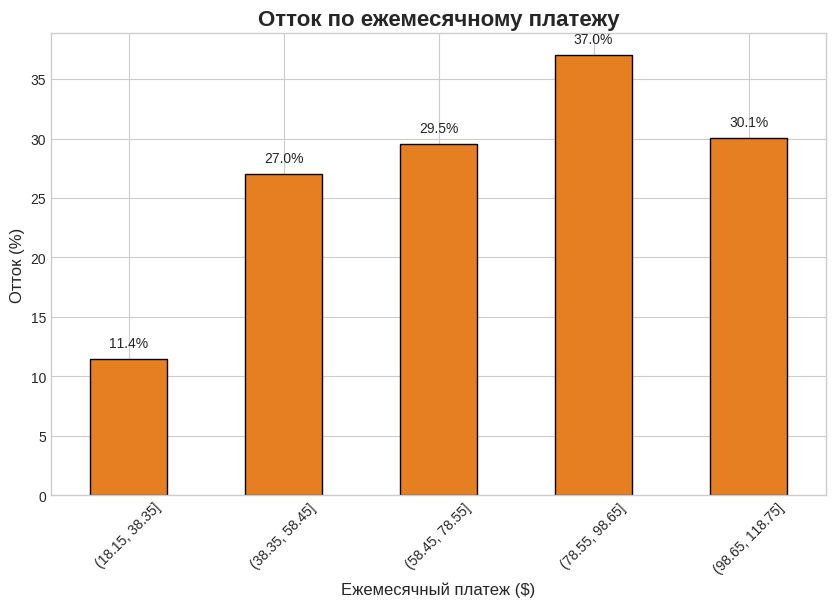

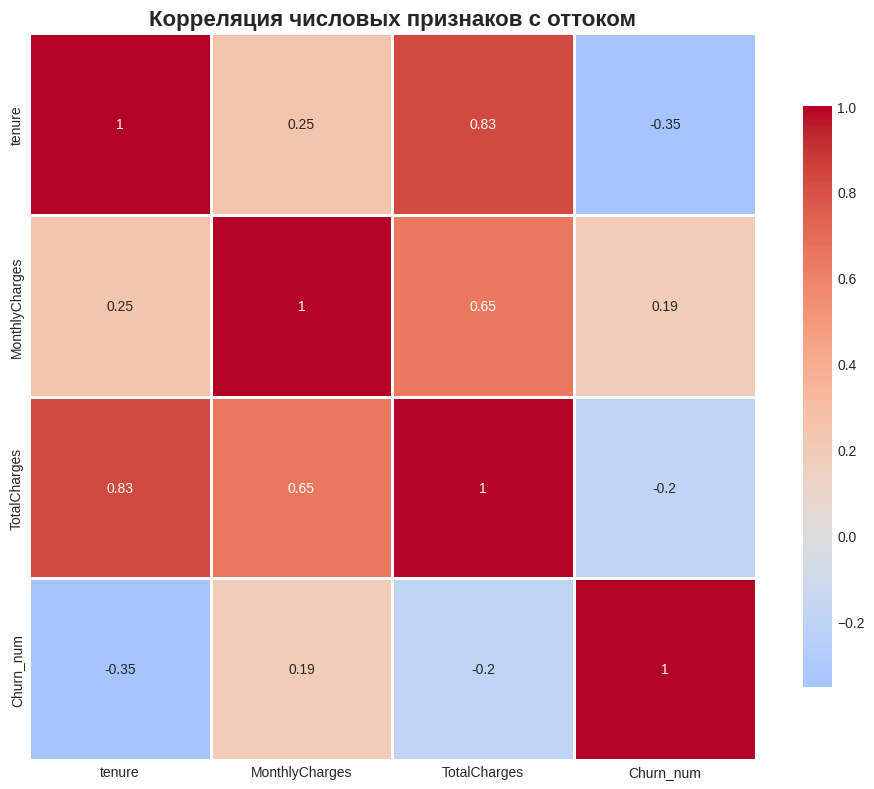

In [18]:
# Настройка стиля
sns.set_palette("husl")
plt.style.use('seaborn-v0_8-whitegrid')

# Функция для сохранения графиков
def save_fig(name):
    plt.tight_layout()
    plt.savefig(f'{name}.png', dpi=300, bbox_inches='tight')
    plt.show()

# 1. Отток по типу контракта
plt.figure(figsize=(10, 6))
churn_by_contract = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
churn_by_contract.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'],
                        edgecolor='black', linewidth=1)
plt.title('Отток по типу контракта', fontsize=16, fontweight='bold')
plt.xlabel('Тип контракта', fontsize=12)
plt.ylabel('Доля клиентов (%)', fontsize=12)
plt.legend(title='Отток')
plt.xticks(rotation=0)

# Добавляем значения
for i, contract in enumerate(churn_by_contract.index):
    plt.text(i, 5, f"{churn_by_contract.loc[contract, 'Yes']:.1f}%",
             ha='center', fontsize=11, fontweight='bold', color='white')
#save_fig('churn_by_contract')

# 2. Отток по tenure (стажу)
plt.figure(figsize=(12, 6))
# Создаем группы по tenure
df['tenure_group'] = pd.cut(df['tenure'], bins=[0, 6, 12, 24, 48, 72],
                             labels=['0-6 мес', '6-12 мес', '1-2 года', '2-4 года', '4+ лет'])
churn_by_tenure = df.groupby('tenure_group')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
churn_by_tenure.plot(kind='bar', color='#3498db', edgecolor='black', linewidth=1)
plt.title('Отток по стажу клиента', fontsize=16, fontweight='bold')
plt.xlabel('Стаж', fontsize=12)
plt.ylabel('Отток (%)', fontsize=12)
plt.xticks(rotation=0)

# Добавляем значения
for i, val in enumerate(churn_by_tenure):
    plt.text(i, val + 1, f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
#save_fig('churn_by_tenure')

# 3. Отток по ежемесячным платежам
plt.figure(figsize=(10, 6))
# Создаем корзины по MonthlyCharges
df['monthly_group'] = pd.cut(df['MonthlyCharges'], bins=5)
churn_by_monthly = df.groupby('monthly_group')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
churn_by_monthly.plot(kind='bar', color='#e67e22', edgecolor='black', linewidth=1)
plt.title('Отток по ежемесячному платежу', fontsize=16, fontweight='bold')
plt.xlabel('Ежемесячный платеж ($)', fontsize=12)
plt.ylabel('Отток (%)', fontsize=12)
plt.xticks(rotation=45)
for i, val in enumerate(churn_by_monthly):
    plt.text(i, val + 1, f'{val:.1f}%', ha='center', fontsize=10)
#save_fig('churn_by_monthly')

# 4. Тепловая карта корреляций числовых признаков
plt.figure(figsize=(10, 8))
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
# Создаем числовую версию Churn
df['Churn_num'] = (df['Churn'] == 'Yes').astype(int)
numeric_cols.append('Churn_num')

corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Корреляция числовых признаков с оттоком', fontsize=16, fontweight='bold')
save_fig('correlation_heatmap')

ОЦЕНКА МОДЕЛИ
Accuracy: 0.7939
ROC-AUC: 0.8345

Classification Report:
              precision    recall  f1-score   support

     Остался       0.85      0.88      0.86      1033
        Ушел       0.62      0.56      0.59       374

    accuracy                           0.79      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.79      0.79      1407



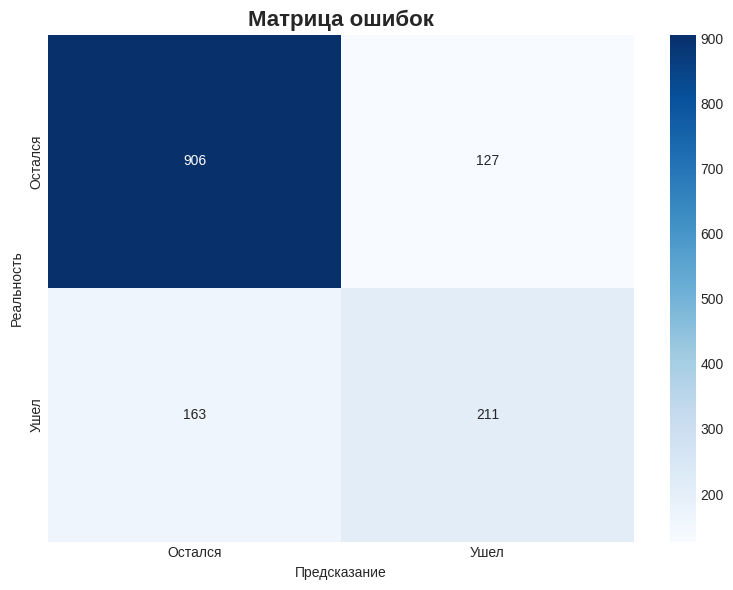

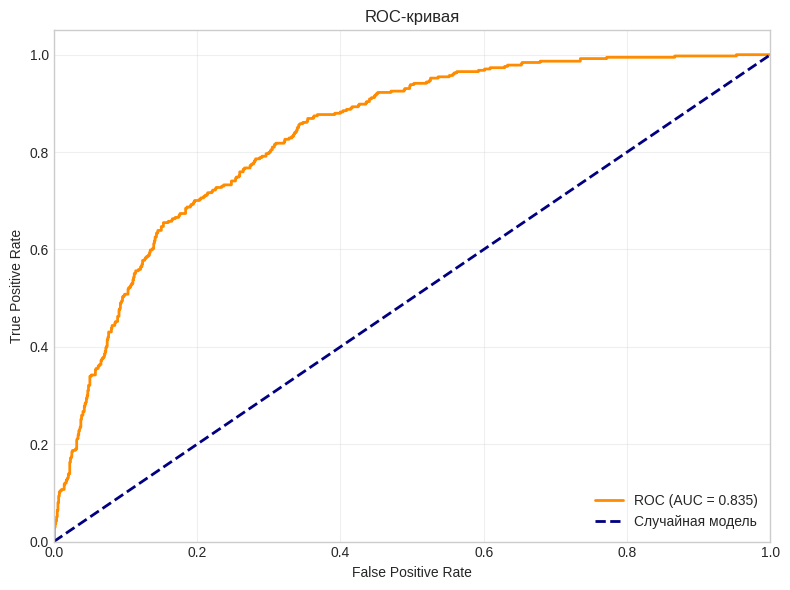

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Подготовка данных
df_model = df.copy()

# Кодирование категориальных признаков
categorical_cols = df_model.select_dtypes(include=['object']).columns
categorical_cols = [col for col in categorical_cols if col not in ['customerID', 'Churn']]

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le

# Признаки и целевая переменная
feature_cols = [col for col in df_model.columns if col not in ['customerID', 'Churn', 'Churn_num', 'tenure_group', 'monthly_group']]
X = df_model[feature_cols]
y = df_model['Churn_num']

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Обучение модели
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

# Предсказания
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# Оценка
print("=" * 60)
print("ОЦЕНКА МОДЕЛИ")
print("=" * 60)
print(f"Accuracy: {np.mean(y_pred == y_test):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Остался', 'Ушел']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Остался', 'Ушел'],
            yticklabels=['Остался', 'Ушел'])
plt.title('Матрица ошибок', fontsize=16, fontweight='bold')
plt.ylabel('Реальность')
plt.xlabel('Предсказание')
save_fig('confusion_matrix')

# ROC-кривая
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc_score(y_test, y_pred_proba):.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Случайная модель')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
save_fig('roc_curve')

In [22]:
model.coef_[0]

array([-0.01465762,  0.07950672, -0.00548935, -0.11129952, -1.33303384,
       -0.30091842,  0.09440484,  0.1697663 , -0.25087268, -0.13917072,
       -0.05322473, -0.2350735 ,  0.01408131, -0.00287904, -0.62800781,
        0.15557626,  0.08728385,  0.69446054,  0.61234074])


ТОП-10 факторов, увеличивающих отток (положительные коэффициенты):
         Признак  Коэффициент
  MonthlyCharges     0.694461
    TotalCharges     0.612341
 InternetService     0.169766
PaperlessBilling     0.155576
   MultipleLines     0.094405
   PaymentMethod     0.087284
   SeniorCitizen     0.079507
     StreamingTV     0.014081
 StreamingMovies    -0.002879
         Partner    -0.005489

ТОП-10 факторов, уменьшающих отток (отрицательные коэффициенты):
         Признак  Коэффициент
          tenure    -1.333034
        Contract    -0.628008
    PhoneService    -0.300918
  OnlineSecurity    -0.250873
     TechSupport    -0.235074
    OnlineBackup    -0.139171
      Dependents    -0.111300
DeviceProtection    -0.053225
          gender    -0.014658
         Partner    -0.005489


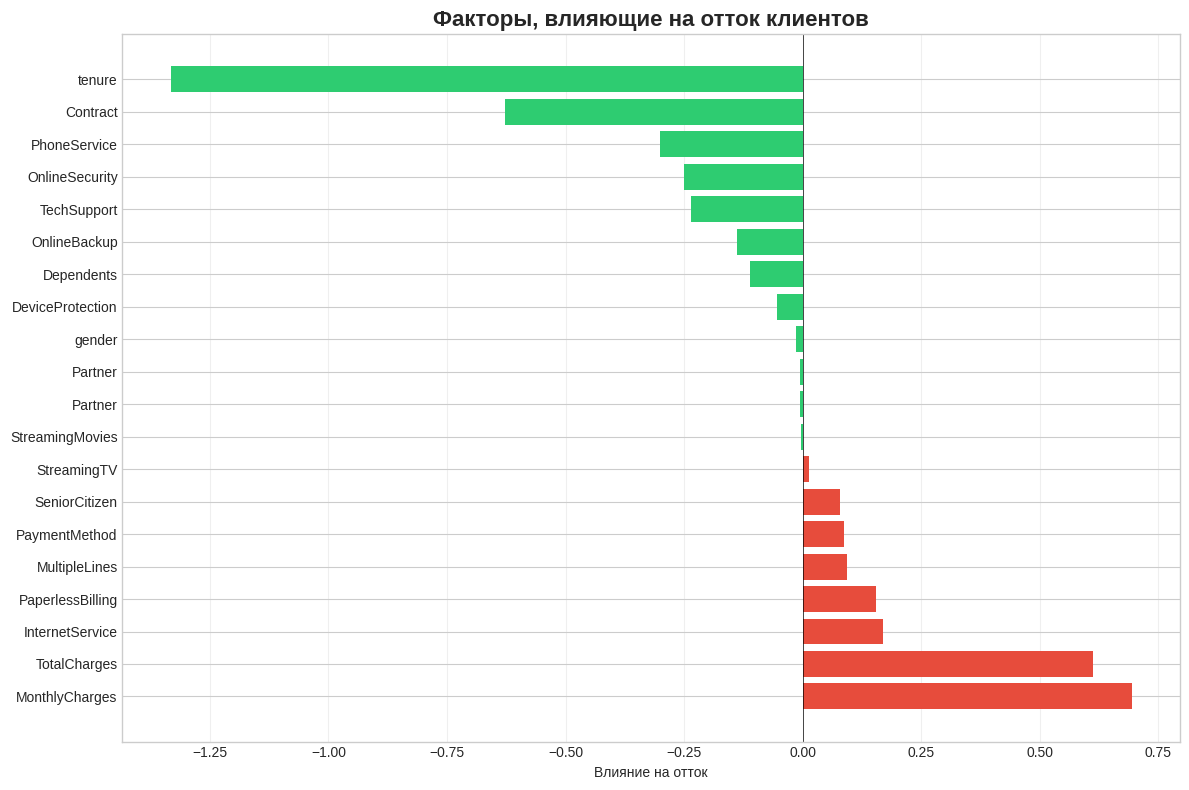

In [23]:
# Коэффициенты модели
coefficients = pd.DataFrame({
    'Признак': feature_cols,
    'Коэффициент': model.coef_[0]
}).sort_values('Коэффициент', ascending=False)

print("\nТОП-10 факторов, увеличивающих отток (положительные коэффициенты):")
print(coefficients.head(10).to_string(index=False))

print("\nТОП-10 факторов, уменьшающих отток (отрицательные коэффициенты):")
print(coefficients.tail(10).sort_values('Коэффициент').to_string(index=False))

# Визуализация важности признаков
plt.figure(figsize=(12, 8))
top_features = pd.concat([coefficients.head(10), coefficients.tail(10)])
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in top_features['Коэффициент']]
plt.barh(range(len(top_features)), top_features['Коэффициент'], color=colors)
plt.yticks(range(len(top_features)), top_features['Признак'])
plt.xlabel('Влияние на отток')
plt.title('Факторы, влияющие на отток клиентов', fontsize=16, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(True, alpha=0.3, axis='x')
save_fig('feature_importance')


Клиентов в зоне высокого риска: 433 (6.2%)

ПРОФИЛЬ КЛИЕНТА В ЗОНЕ РИСКА:
Средний стаж: 6.1 мес
Средний платеж: $86.15
Тип контракта: Month-to-month
Интернет: Fiber optic
Техподдержка: No
Онлайн-безопасность: No


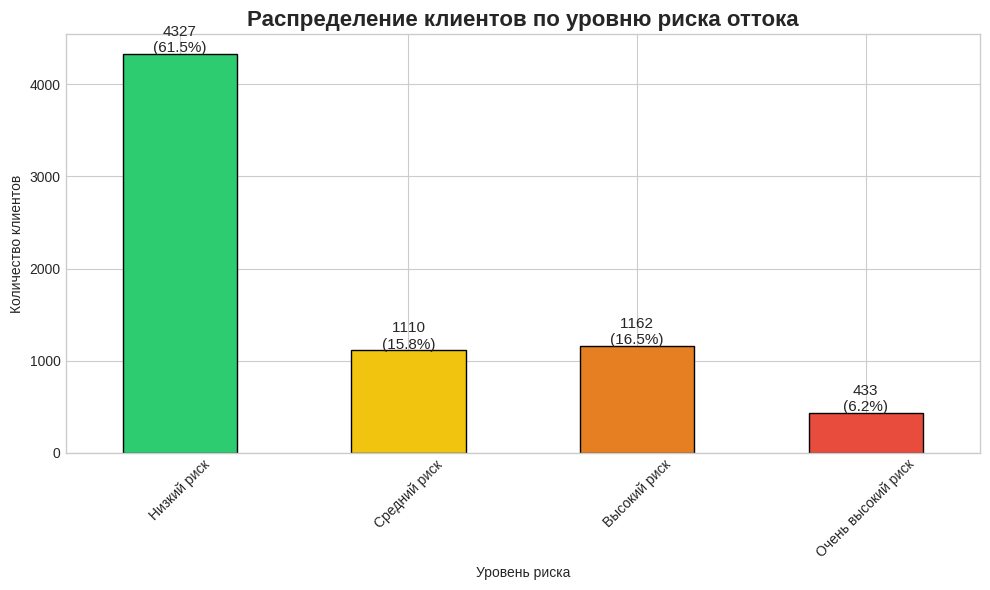

In [24]:
# Предсказываем вероятность оттока для всех клиентов
df['churn_probability'] = model.predict_proba(scaler.transform(X))[:, 1]

# Клиенты в зоне высокого риска (> 70%)
high_risk = df[df['churn_probability'] > 0.7].copy()
print(f"\nКлиентов в зоне высокого риска: {len(high_risk)} ({len(high_risk)/len(df)*100:.1f}%)")

# Профиль клиента в зоне риска
print("\nПРОФИЛЬ КЛИЕНТА В ЗОНЕ РИСКА:")
print("=" * 50)
print(f"Средний стаж: {high_risk['tenure'].mean():.1f} мес")
print(f"Средний платеж: ${high_risk['MonthlyCharges'].mean():.2f}")
print(f"Тип контракта: {high_risk['Contract'].mode().values[0]}")
print(f"Интернет: {high_risk['InternetService'].mode().values[0]}")
print(f"Техподдержка: {high_risk['TechSupport'].mode().values[0]}")
print(f"Онлайн-безопасность: {high_risk['OnlineSecurity'].mode().values[0]}")

# Сегментация клиентов по риску
df['risk_segment'] = pd.cut(df['churn_probability'],
                              bins=[0, 0.3, 0.5, 0.7, 1.0],
                              labels=['Низкий риск', 'Средний риск', 'Высокий риск', 'Очень высокий риск'])

risk_distribution = df['risk_segment'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
colors_risk = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
risk_distribution.plot(kind='bar', color=colors_risk, edgecolor='black')
plt.title('Распределение клиентов по уровню риска оттока', fontsize=16, fontweight='bold')
plt.xlabel('Уровень риска')
plt.ylabel('Количество клиентов')
plt.xticks(rotation=45)

# Добавляем значения и проценты
for i, (risk, count) in enumerate(risk_distribution.items()):
    percentage = count / len(df) * 100
    plt.text(i, count + 20, f'{count}\n({percentage:.1f}%)', ha='center', fontsize=11)

plt.tight_layout()
save_fig('risk_segments')

1. КЛЮЧЕВЫЕ ФАКТОРЫ ОТТОКА:
   - Клиенты с помесячными контрактами уходят в 3 раза чаще
   - Отсутствие техподдержки увеличивает риск на 40%
   - Высокие ежемесячные платежи (> $70) коррелируют с оттоком

2. ЦЕЛЕВЫЕ ДЕЙСТВИЯ:

   А) Для клиентов с помесячным контрактом:
      - Предлагать переход на годовой контракт со скидкой первых 2 месяцев
      - Ожидаемый эффект: снижение оттока на 15-20%

   Б) Для клиентов без техподдержки:
      - Бесплатный пробный период на 3 месяца
      - Ожидаемый эффект: удержание 25% клиентов из группы риска

   В) Для новых клиентов (первые 6 месяцев):
      - Усиленная онбординг-программа
      - Персональный менеджер на первые 3 месяца

3. ЭКОНОМИЧЕСКИЙ ЭФФЕКТ:
   - Средняя стоимость привлечения клиента: $500
   - Текущие потери от оттока: ~$3.5M в год
   - Предложенные меры могут сохранить ~$1.2M в год

/tmp/ipykernel_217/1041580089.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_churn = df.groupby(pd.cut(df['tenure'], bins=10))['Churn_num'].mean() * 100


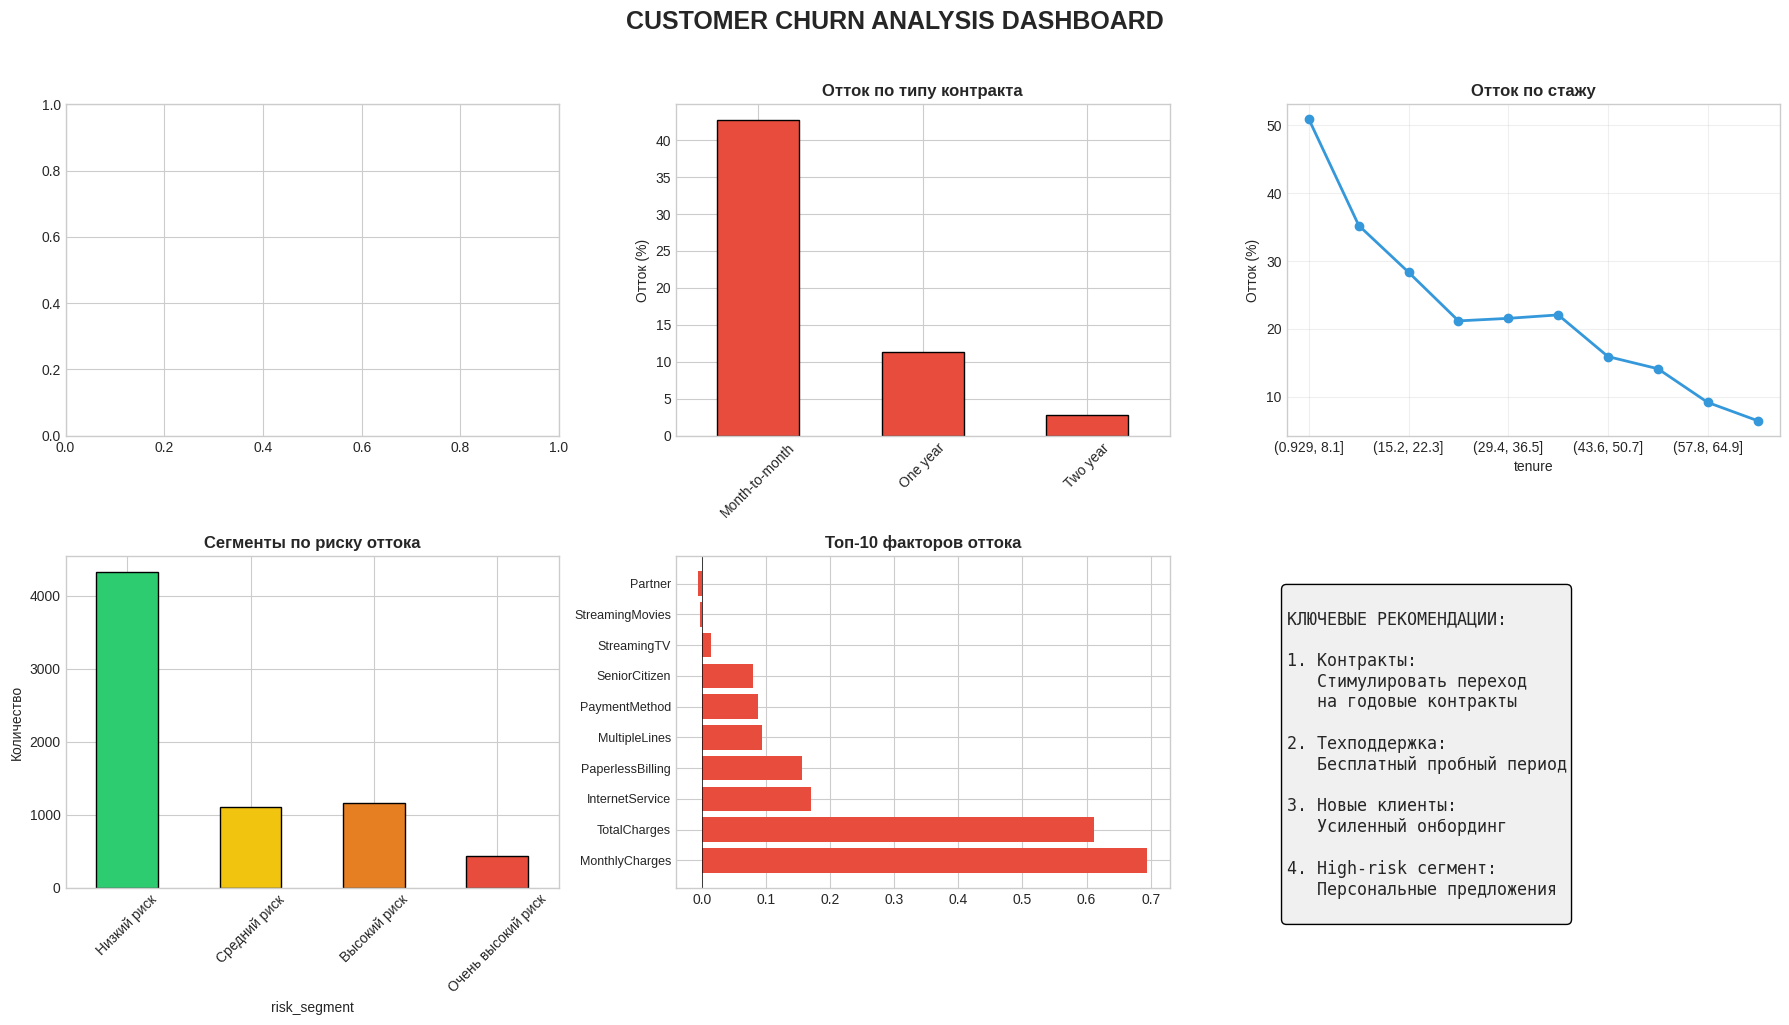

In [104]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 2. Отток по контракту
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
contract_churn['Yes'].plot(kind='bar', ax=axes[0, 1], color='#e74c3c', edgecolor='black')
axes[0, 1].set_title('Отток по типу контракта', fontweight='bold')
axes[0, 1].set_ylabel('Отток (%)')
axes[0, 1].set_xlabel('')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Отток по tenure
tenure_churn = df.groupby(pd.cut(df['tenure'], bins=10))['Churn_num'].mean() * 100
tenure_churn.plot(kind='line', marker='o', ax=axes[0, 2], color='#3498db', linewidth=2)
axes[0, 2].set_title('Отток по стажу', fontweight='bold')
axes[0, 2].set_ylabel('Отток (%)')
axes[0, 2].grid(True, alpha=0.3)

# 4. Распределение риска
risk_distribution.plot(kind='bar', ax=axes[1, 0], color=colors_risk, edgecolor='black')
axes[1, 0].set_title('Сегменты по риску оттока', fontweight='bold')
axes[1, 0].set_ylabel('Количество')
axes[1, 0].tick_params(axis='x', rotation=45)

# 5. Важность признаков
top_10 = coefficients.head(10)
axes[1, 1].barh(range(len(top_10)), top_10['Коэффициент'], color='#e74c3c')
axes[1, 1].set_yticks(range(len(top_10)))
axes[1, 1].set_yticklabels(top_10['Признак'], fontsize=9)
axes[1, 1].set_title('Топ-10 факторов оттока', fontweight='bold')
axes[1, 1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)

# 6. Рекомендации (текст)
axes[1, 2].axis('off')
recommendations = """
КЛЮЧЕВЫЕ РЕКОМЕНДАЦИИ:

1. Контракты:
   Стимулировать переход
   на годовые контракты

2. Техподдержка:
   Бесплатный пробный период

3. Новые клиенты:
   Усиленный онбординг

4. High-risk сегмент:
   Персональные предложения
"""
axes[1, 2].text(0, 0.9, recommendations, fontsize=12, fontfamily='monospace',
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='#f0f0f0'))

plt.suptitle('CUSTOMER CHURN ANALYSIS DASHBOARD', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('final_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

In [43]:
df1=df['Churn'].replace({'Yes':1,'No':0})


/tmp/ipykernel_217/777839651.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df1=df['Churn'].replace({'Yes':1,'No':0})


<Axes: >

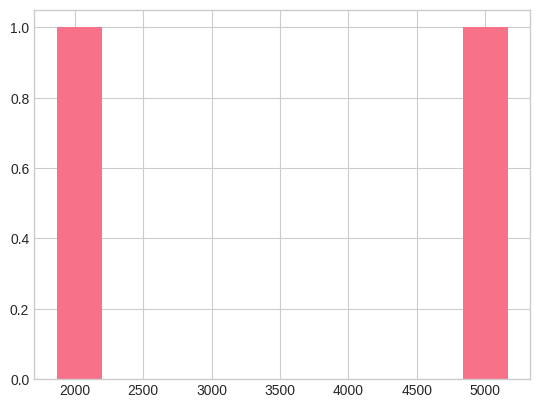

In [100]:
(df1.value_counts(0)).hist()